# Word Embeddings: Learning Semantic Meaning from Text

This notebook is the third notebook in the **AI NLP LLM Notes** learning path.

The previous notebooks introduced TF-IDF and conceptual word vectors. Here, we move from manually designed vector spaces to **learned word embeddings**: dense representations learned from text data.

# Introduction

TF-IDF creates sparse lexical representations where each dimension usually corresponds to a term in the vocabulary. Word vectors introduced the idea of dense semantic spaces, where words can be compared geometrically.

**Word embeddings** are learned word vectors. Instead of manually assigning dimensions such as `medical`, `finance`, or `sports`, embedding algorithms learn useful numerical representations from word co-occurrence patterns in text.

This makes embeddings more scalable and more realistic than hand-coded examples. Similar words can appear close in vector space because they occur in similar contexts.

## From Word Vectors to Word Embeddings

The previous notebook used manually defined vectors to explain the geometry of semantic spaces. That is useful for intuition, but it does not scale.

In real NLP systems, embeddings are **learned from data**. The model observes many examples of words appearing near other words and adjusts vector values so that words used in similar contexts receive similar representations.

This is the core distributional idea behind many embedding methods: **a word is partly defined by the company it keeps**.

## Why Word Embeddings Matter

Embeddings are useful because they support:

- **semantic similarity**: `doctor` and `physician` can become close even if they are different strings,
- **better generalization**: models can transfer patterns across related words,
- **compact representation**: dense vectors are smaller than large sparse vocabularies,
- **improved downstream NLP performance**: embeddings can be used as inputs for classifiers, search systems, and neural networks.

Examples of relationships embeddings can learn include `doctor / physician`, `king / queen`, `machine / learning`, and `finance / banking`.

In [2]:
!pip install gensim
import random
import re
import string

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA

try:
    from gensim.models import Word2Vec
except ImportError as error:
    raise ImportError(
        "This notebook requires gensim. Install it with: pip install gensim"
    ) from error

  Obtaining dependency information for gensim from https://files.pythonhosted.org/packages/38/7c/18d40f341276a7461962512ca1fb716d5982db57615dfa272f651ecb96d7/gensim-4.4.0-cp311-cp311-macosx_11_0_arm64.whl.metadata
  Obtaining dependency information for smart_open>=1.8.1 from https://files.pythonhosted.org/packages/b4/bd/1c92e69a1daff70118f21e18ef3a100c114f00f08b64a1074484f12d9020/smart_open-8.0.0-py3-none-any.whl.metadata
  Obtaining dependency information for wrapt from https://files.pythonhosted.org/packages/7d/b5/5c0b093eb48f8a062ef6267d3cb36e9bb1b88440181f6545a383c60efdf8/wrapt-2.2.2-cp311-cp311-macosx_11_0_arm64.whl.metadata
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 2.1 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.0/73.0 kB 1.6 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.7/81.7 kB 2.5 MB/s eta 0:00:00
DEPRECATION: textract 1.6.5 has a non-standard dependency specifier extract-msg<=0.29.*. pip 23.3 will enforc

In [3]:
RANDOM_SEED = 42

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

plt.rcParams.update(
    {
        "figure.figsize": (10, 6),
        "figure.dpi": 120,
        "axes.facecolor": "#FAFAFA",
        "axes.edgecolor": "#333333",
        "axes.labelcolor": "#222222",
        "axes.titleweight": "bold",
        "axes.titlesize": 14,
        "axes.labelsize": 11,
        "font.family": "DejaVu Sans",
        "grid.color": "#DDDDDD",
        "grid.linestyle": "-",
        "grid.linewidth": 0.8,
        "xtick.color": "#222222",
        "ytick.color": "#222222",
    }
)

PRIMARY_COLOR = "#2F6F9F"
SECONDARY_COLOR = "#D95F59"
ACCENT_COLOR = "#3A9D7C"
WARNING_COLOR = "#E0A23B"
NEUTRAL_COLOR = "#6B7280"

## Tiny Corpus

The corpus below is intentionally small but realistic. It includes repeated semantic patterns across healthcare, finance, software engineering, machine learning, cybersecurity, education, customer support, and a few analogy-oriented sentences.

Real embeddings are normally trained on millions or billions of tokens. This tiny corpus is designed for education and fast execution, not production-quality embeddings.

In [4]:
corpus = [
    "The doctor reviewed patient symptoms and updated the hospital treatment plan.",
    "A nurse monitored the patient in the hospital and reported changes to the doctor.",
    "The physician discussed diagnosis and medication with the nurse and patient.",
    "Clinical teams use medical records to improve patient care in the hospital.",
    "The bank analyzed credit risk before approving the finance application.",
    "Finance analysts reviewed banking transactions for fraud and unusual payments.",
    "The customer asked the bank about a delayed payment and account balance.",
    "Risk teams monitor market volatility and banking exposure for finance leaders.",
    "Machine learning engineers train a model with clean data and validation metrics.",
    "The model improved after training on more labeled data from production logs.",
    "Data scientists compare model performance during machine learning experiments.",
    "Feature engineering helps the learning model detect patterns in customer behavior.",
    "Software engineers deploy services after code review and automated testing.",
    "A backend engineer fixed an API bug discovered during integration testing.",
    "Continuous integration runs tests before software teams release production code.",
    "Security analysts detected a threat in authentication logs and blocked access.",
    "Cybersecurity teams investigate phishing attacks and protect user credentials.",
    "The security team patched a vulnerability after threat intelligence alerts.",
    "Education platforms personalize learning exercises for students and teachers.",
    "Teachers review student progress and adapt lessons for online education.",
    "Customer support agents resolve billing tickets and answer product questions.",
    "The chatbot routes customer issues to support agents when confidence is low.",
    "The king and queen attended a royal ceremony with the prince and princess.",
    "The man and woman discussed leadership roles in the royal family.",
    "A queen can rule a kingdom just as a king can lead a kingdom.",
    "Football coaches analyze player performance while basketball coaches review team strategy.",
]

corpus_df = pd.DataFrame(
    {
        "document_id": [f"SENT_{index:02d}" for index in range(1, len(corpus) + 1)],
        "text": corpus,
    }
)

display(corpus_df)

,document_id,text
0,SENT_01,The doctor reviewed patient symptoms and updat...
1,SENT_02,A nurse monitored the patient in the hospital ...
2,SENT_03,The physician discussed diagnosis and medicati...
3,SENT_04,Clinical teams use medical records to improve ...
4,SENT_05,The bank analyzed credit risk before approving...
5,SENT_06,Finance analysts reviewed banking transactions...
6,SENT_07,The customer asked the bank about a delayed pa...
7,SENT_08,Risk teams monitor market volatility and banki...
8,SENT_09,Machine learning engineers train a model with ...
9,SENT_10,The model improved after training on more labe...


## Text Preprocessing

The preprocessing pipeline is deliberately simple:

1. lowercase the text,
2. remove punctuation,
3. tokenize into words.

For a production system, preprocessing would depend on the language, domain, and model. Here, readability is more important than aggressive normalization.

In [5]:
def preprocess_text(text):
    """Lowercase text, remove punctuation, and split into tokens."""
    lowercase_text = text.lower()
    text_without_punctuation = lowercase_text.translate(
        str.maketrans("", "", string.punctuation)
    )
    tokens = re.findall(r"\b[a-z]+\b", text_without_punctuation)
    return tokens


tokenized_corpus = [preprocess_text(sentence) for sentence in corpus]
corpus_df["tokens"] = tokenized_corpus

display(corpus_df[["document_id", "tokens"]].head(8))

,document_id,tokens
0,SENT_01,"[the, doctor, reviewed, patient, symptoms, and..."
1,SENT_02,"[a, nurse, monitored, the, patient, in, the, h..."
2,SENT_03,"[the, physician, discussed, diagnosis, and, me..."
3,SENT_04,"[clinical, teams, use, medical, records, to, i..."
4,SENT_05,"[the, bank, analyzed, credit, risk, before, ap..."
5,SENT_06,"[finance, analysts, reviewed, banking, transac..."
6,SENT_07,"[the, customer, asked, the, bank, about, a, de..."
7,SENT_08,"[risk, teams, monitor, market, volatility, and..."


## Training Word2Vec Embeddings

Word2Vec learns word embeddings by using nearby words as context.

There are two classic training strategies:

- **CBOW** predicts a target word from surrounding context words.
- **Skip-gram** predicts surrounding context words from a target word.

Skip-gram often works well for learning meaningful representations, especially when the corpus contains rare words. In this notebook, we train a small skip-gram model.

Key parameters:

- `vector_size`: number of dimensions in each word vector,
- `window`: number of surrounding words used as context,
- `min_count`: minimum frequency needed for a word to enter the vocabulary,
- `sg`: training mode; `1` means skip-gram and `0` means CBOW,
- `epochs`: number of passes through the corpus,
- `seed`: random seed for reproducibility.

In [6]:
def train_word2vec_model(
    sentences,
    vector_size=50,
    window=4,
    min_count=1,
    sg=1,
    epochs=250,
    seed=RANDOM_SEED,
):
    """Train and return a lightweight Word2Vec model."""
    model = Word2Vec(
        sentences=sentences,
        vector_size=vector_size,
        window=window,
        min_count=min_count,
        sg=sg,
        workers=1,
        epochs=epochs,
        seed=seed,
    )
    return model


embedding_model = train_word2vec_model(tokenized_corpus)
print("Word2Vec model trained successfully.")

Word2Vec model trained successfully.


## Inspecting the Vocabulary

After training, Word2Vec stores learned vectors in `model.wv`. Every word in the learned vocabulary has a dense numeric vector with the configured number of dimensions.

The values are learned parameters. A single dimension is not usually interpretable by itself; meaning is distributed across the full vector.

In [7]:
vocabulary = embedding_model.wv.index_to_key
vocabulary_size = len(vocabulary)
vector_shape = embedding_model.wv[vocabulary[0]].shape

print(f"Vocabulary size: {vocabulary_size}")
print(f"Vector shape for one word: {vector_shape}")
print(f"First 25 vocabulary terms: {vocabulary[:25]}")

Vocabulary size: 173
Vector shape for one word: (50,)
First 25 vocabulary terms: ['the', 'and', 'a', 'in', 'model', 'learning', 'customer', 'for', 'teams', 'patient', 'review', 'after', 'data', 'finance', 'with', 'to', 'hospital', 'coaches', 'kingdom', 'can', 'royal', 'queen', 'king', 'agents', 'support']


In [8]:
def get_word_vector_table(model, words, dimensions=8):
    """Return a small table with the first vector dimensions for selected words."""
    rows = []
    for word in words:
        if word not in model.wv:
            continue

        vector = model.wv[word][:dimensions]
        rows.append(
            {
                "word": word,
                **{
                    f"dim_{index + 1}": value
                    for index, value in enumerate(vector)
                },
            }
        )
    return pd.DataFrame(rows)


sample_vector_table = get_word_vector_table(
    embedding_model,
    ["doctor", "nurse", "finance", "model", "security"],
)

display(sample_vector_table.round(4))

,word,dim_1,dim_2,dim_3,dim_4,dim_5,dim_6,dim_7,dim_8
0,doctor,0.0606,-0.2631,-0.3626,0.1965,0.2744,0.5469,-0.3987,0.1252
1,nurse,0.1821,-0.4141,-0.3036,0.0836,0.2130,0.4884,-0.4414,0.0605
2,finance,0.2871,-0.4502,-0.1630,-0.0459,0.2308,-0.2052,-0.4264,0.3459
3,model,-0.0536,0.3651,-0.1832,-0.4807,0.2969,0.0070,-0.2091,0.3909
4,security,-0.0169,-0.2636,-0.0112,0.0398,-0.2912,-0.1749,-0.1364,0.4778


## Measuring Semantic Similarity

Word2Vec provides `model.wv.similarity(word_a, word_b)`, which computes cosine similarity between two learned word vectors.

The helper below handles missing words safely so the notebook remains robust when experimenting with different corpora or `min_count` values.

In [9]:
def safe_similarity(model, word_a, word_b):
    """Return cosine similarity for two words, or NaN if either is missing."""
    missing_words = [word for word in [word_a, word_b] if word not in model.wv]
    if missing_words:
        return np.nan
    return float(model.wv.similarity(word_a, word_b))


similarity_pairs = [
    ("doctor", "nurse"),
    ("doctor", "hospital"),
    ("bank", "finance"),
    ("football", "hospital"),
    ("model", "training"),
    ("security", "threat"),
]

similarity_results = pd.DataFrame(
    {
        "word_a": word_a,
        "word_b": word_b,
        "similarity": safe_similarity(embedding_model, word_a, word_b),
    }
    for word_a, word_b in similarity_pairs
)

display(similarity_results.round(3))

,word_a,word_b,similarity
0,doctor,nurse,0.876
1,doctor,hospital,0.985
2,bank,finance,0.611
3,football,hospital,0.259
4,model,training,0.714
5,security,threat,0.986


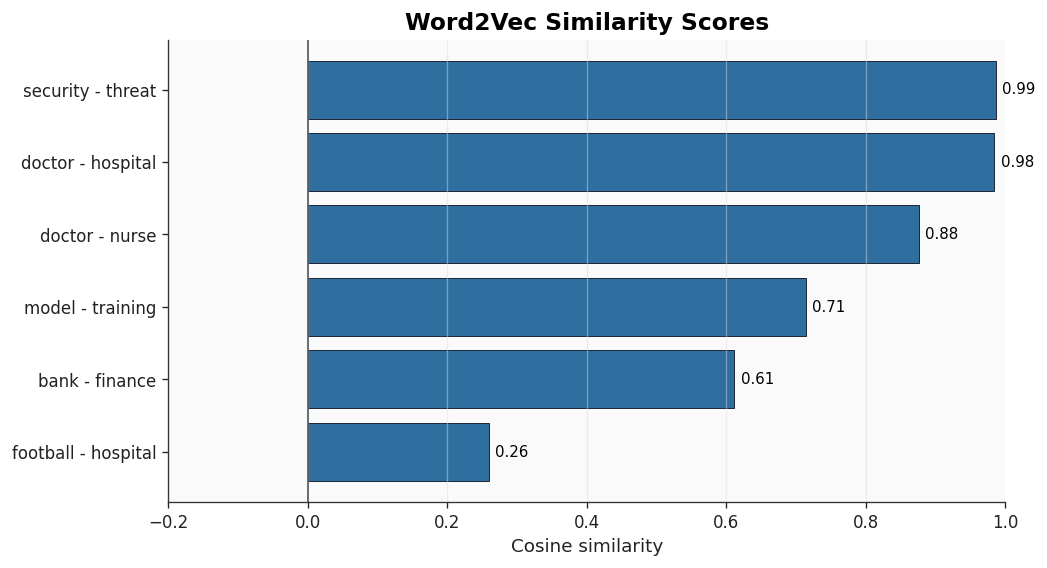

In [10]:
def plot_similarity_bars(similarity_table):
    """Plot pairwise similarity scores as a horizontal bar chart."""
    plot_table = similarity_table.copy()
    plot_table["pair"] = plot_table["word_a"] + " - " + plot_table["word_b"]
    plot_table = plot_table.sort_values("similarity")

    fig, ax = plt.subplots(figsize=(9, 5))
    bars = ax.barh(
        plot_table["pair"],
        plot_table["similarity"],
        color=PRIMARY_COLOR,
        edgecolor="#1F2937",
        linewidth=0.6,
    )

    ax.set_title("Word2Vec Similarity Scores")
    ax.set_xlabel("Cosine similarity")
    ax.set_xlim(-0.2, 1.0)
    ax.axvline(0, color="#4B5563", linewidth=1)
    ax.bar_label(bars, fmt="%.2f", padding=4, fontsize=9)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="x", alpha=0.45)
    plt.show()


plot_similarity_bars(similarity_results)

## Most Similar Words

`most_similar` returns the nearest words in the learned embedding space. On a tiny corpus, the results are educational rather than production-grade. Still, they show how embeddings can support semantic exploration.

In [11]:
def get_most_similar_words(model, word, top_n=5):
    """Return the most similar words to a query word as a DataFrame."""
    if word not in model.wv:
        return pd.DataFrame(
            [{"query_word": word, "similar_word": None, "similarity": np.nan}]
        )

    similar_words = model.wv.most_similar(word, topn=top_n)
    return pd.DataFrame(
        {
            "query_word": word,
            "similar_word": similar_word,
            "similarity": similarity,
        }
        for similar_word, similarity in similar_words
    )


query_words = ["doctor", "finance", "model", "security", "customer"]
most_similar_tables = [
    get_most_similar_words(embedding_model, word, top_n=5)
    for word in query_words
]
most_similar_df = pd.concat(most_similar_tables, ignore_index=True)

display(most_similar_df.round(3))

,query_word,similar_word,similarity
0,doctor,hospital,0.985
1,doctor,plan,0.973
2,doctor,patient,0.973
3,doctor,symptoms,0.973
4,doctor,changes,0.972
5,finance,banking,0.956
6,finance,leaders,0.948
7,finance,exposure,0.946
8,finance,volatility,0.939
9,finance,monitor,0.938


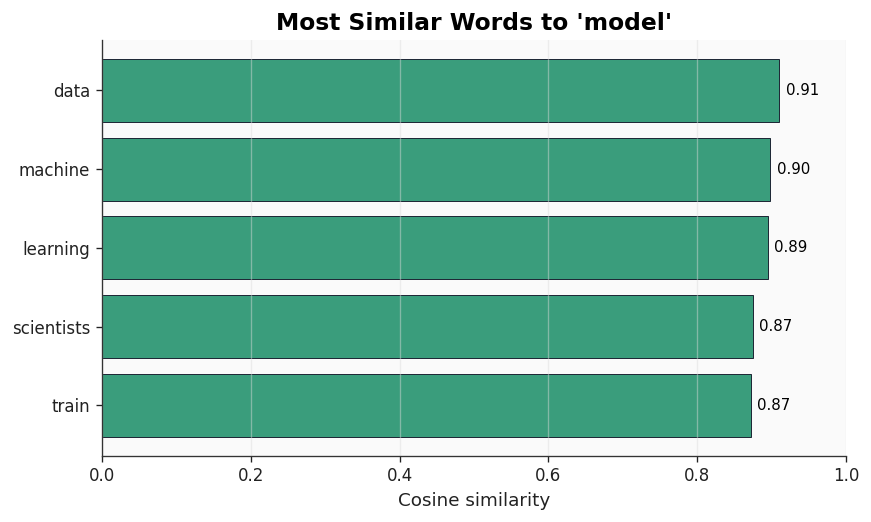

In [12]:
def plot_most_similar_for_word(model, word, top_n=5):
    """Plot the top similar words for one query word."""
    similar_table = get_most_similar_words(model, word, top_n=top_n)
    similar_table = similar_table.sort_values("similarity")

    fig, ax = plt.subplots(figsize=(8, 4.5))
    bars = ax.barh(
        similar_table["similar_word"],
        similar_table["similarity"],
        color=ACCENT_COLOR,
        edgecolor="#1F2937",
        linewidth=0.6,
    )

    ax.set_title(f"Most Similar Words to '{word}'")
    ax.set_xlabel("Cosine similarity")
    ax.set_xlim(0, 1)
    ax.bar_label(bars, fmt="%.2f", padding=4, fontsize=9)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="x", alpha=0.45)
    plt.show()


plot_most_similar_for_word(embedding_model, "model", top_n=5)

## Visualizing Embeddings

Embeddings are usually too high-dimensional to plot directly. PCA reduces the vectors to two dimensions so we can inspect rough neighborhoods and clusters.

Clusters in a PCA plot should be interpreted carefully. They are a simplified projection of a higher-dimensional space, but they are useful for building intuition.

In [13]:
selected_words = [
    "doctor",
    "nurse",
    "hospital",
    "patient",
    "bank",
    "finance",
    "payment",
    "model",
    "training",
    "learning",
    "security",
    "threat",
    "customer",
    "support",
    "teacher",
    "student",
    "king",
    "queen",
    "football",
    "basketball",
]


def build_projection_table(model, words):
    """Project selected word embeddings into two dimensions with PCA."""
    available_words = [word for word in words if word in model.wv]
    vectors = np.array([model.wv[word] for word in available_words])
    coordinates = PCA(n_components=2, random_state=RANDOM_SEED).fit_transform(vectors)
    return pd.DataFrame(
        {
            "word": available_words,
            "x": coordinates[:, 0],
            "y": coordinates[:, 1],
        }
    )


projection_df = build_projection_table(embedding_model, selected_words)
display(projection_df.round(3))

,word,x,y
0,doctor,1.316,-0.307
1,nurse,1.106,-0.081
2,hospital,1.486,-0.374
3,patient,1.522,-0.315
4,bank,0.508,0.415
5,finance,0.235,0.578
6,payment,0.417,0.487
7,model,-1.009,-0.950
8,training,-0.618,-0.766
9,learning,-1.013,-0.838


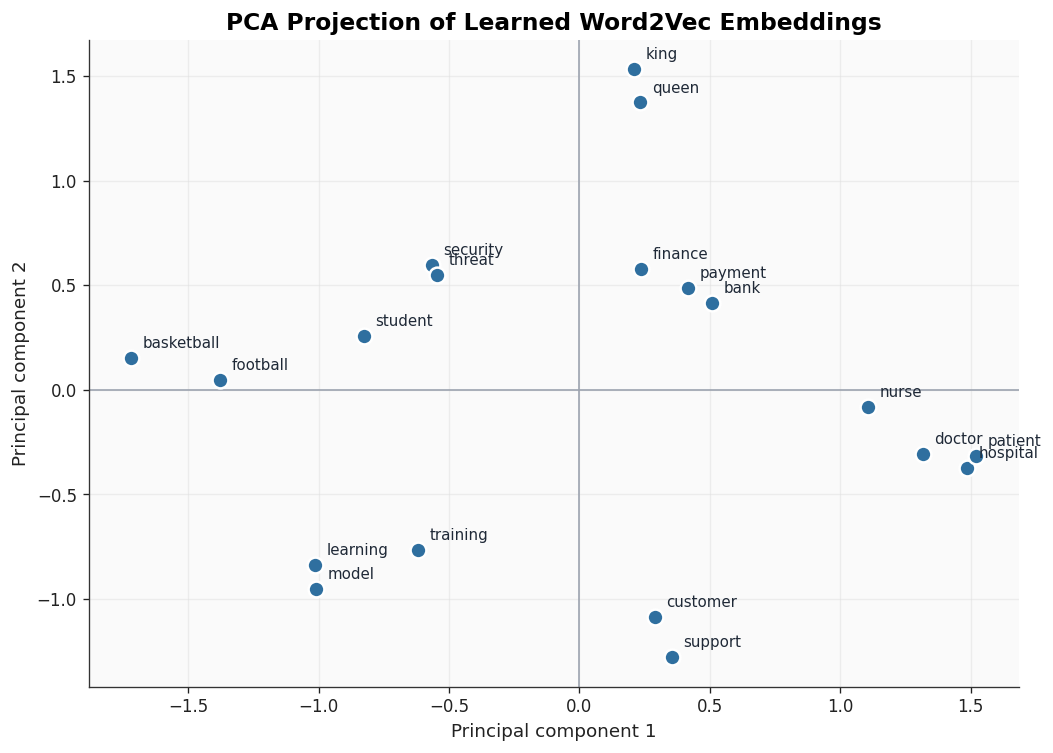

In [14]:
def plot_embedding_projection(projection_table):
    """Plot a 2D PCA projection of selected learned word embeddings."""
    fig, ax = plt.subplots(figsize=(10, 7))
    ax.scatter(
        projection_table["x"],
        projection_table["y"],
        s=90,
        color=PRIMARY_COLOR,
        edgecolor="white",
        linewidth=1.5,
        zorder=3,
    )

    for row in projection_table.itertuples(index=False):
        ax.annotate(
            row.word,
            (row.x, row.y),
            xytext=(7, 6),
            textcoords="offset points",
            fontsize=9,
            color="#1F2937",
        )

    ax.axhline(0, color="#9CA3AF", linewidth=1)
    ax.axvline(0, color="#9CA3AF", linewidth=1)
    ax.set_title("PCA Projection of Learned Word2Vec Embeddings")
    ax.set_xlabel("Principal component 1")
    ax.set_ylabel("Principal component 2")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(True, alpha=0.45)
    plt.show()


plot_embedding_projection(projection_df)

## Comparing Embedding Dimensions

The `vector_size` parameter controls how many values represent each word. Larger vectors can represent more nuance, but they also require more memory and more training data.

On a tiny corpus, increasing dimensionality does not guarantee better embeddings. It may simply give the model more room to memorize weak patterns.

In [15]:
def compare_vector_sizes(sentences, vector_sizes):
    """Train Word2Vec models with different vector sizes and compare outputs."""
    rows = []
    for vector_size in vector_sizes:
        model = train_word2vec_model(
            sentences,
            vector_size=vector_size,
            window=4,
            min_count=1,
            sg=1,
            epochs=250,
            seed=RANDOM_SEED,
        )

        rows.append(
            {
                "vector_size": vector_size,
                "vocabulary_size": len(model.wv.index_to_key),
                "vector_shape": model.wv["doctor"].shape,
                "doctor_nurse_similarity": safe_similarity(model, "doctor", "nurse"),
                "bank_finance_similarity": safe_similarity(model, "bank", "finance"),
                "model_training_similarity": safe_similarity(model, "model", "training"),
            }
        )

    return pd.DataFrame(rows)


dimension_comparison_df = compare_vector_sizes(tokenized_corpus, [10, 30, 50])
display(dimension_comparison_df.round(3))

,vector_size,vocabulary_size,vector_shape,doctor_nurse_similarity,bank_finance_similarity,model_training_similarity
0,10,173,"(10,)",0.836,0.729,0.766
1,30,173,"(30,)",0.901,0.699,0.707
2,50,173,"(50,)",0.876,0.611,0.714


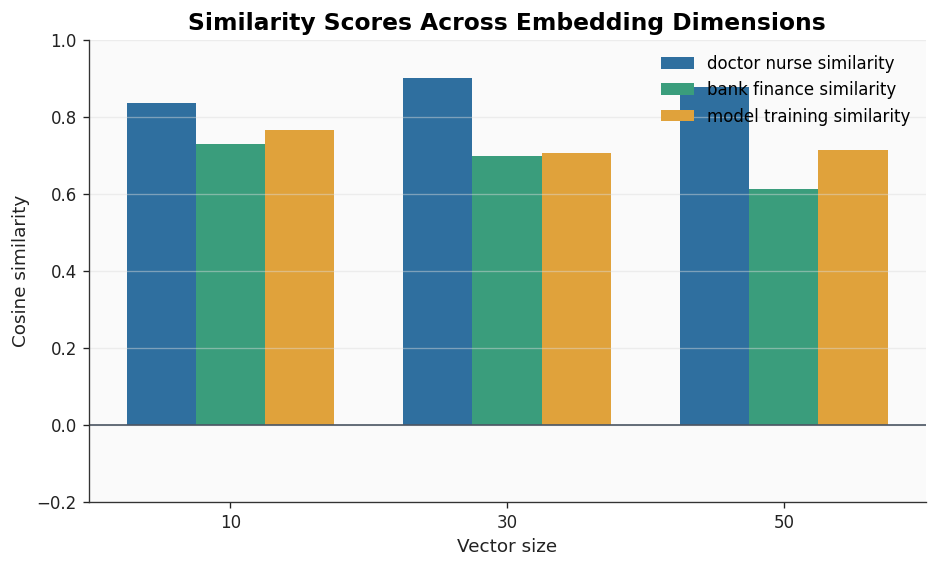

In [16]:
def plot_dimension_comparison(comparison_table):
    """Plot how sample similarities change across vector dimensions."""
    fig, ax = plt.subplots(figsize=(9, 5))
    x_positions = np.arange(len(comparison_table))
    bar_width = 0.25

    metrics = [
        "doctor_nurse_similarity",
        "bank_finance_similarity",
        "model_training_similarity",
    ]
    colors = [PRIMARY_COLOR, ACCENT_COLOR, WARNING_COLOR]

    for index, metric in enumerate(metrics):
        ax.bar(
            x_positions + (index - 1) * bar_width,
            comparison_table[metric],
            width=bar_width,
            label=metric.replace("_", " "),
            color=colors[index],
        )

    ax.set_title("Similarity Scores Across Embedding Dimensions")
    ax.set_xlabel("Vector size")
    ax.set_ylabel("Cosine similarity")
    ax.set_xticks(x_positions)
    ax.set_xticklabels(comparison_table["vector_size"])
    ax.set_ylim(-0.2, 1.0)
    ax.axhline(0, color="#4B5563", linewidth=1)
    ax.legend(frameon=False, loc="best")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", alpha=0.45)
    plt.show()


plot_dimension_comparison(dimension_comparison_df)

## Word Analogies Concept

A famous example of embedding arithmetic is:

\[
\text{king} - \text{man} + \text{woman} \approx \text{queen}
\]

This works well only when the model has learned stable relationship directions from enough data. Our corpus includes a few royalty examples, but it is far too small to expect reliable analogy behavior.

The code below attempts the analogy and reports the nearest words. Treat the result as a diagnostic, not as evidence of production-quality semantic reasoning.

In [17]:
def solve_analogy(model, positive_words, negative_words=None, top_n=5):
    """Solve a vector analogy with safe handling for missing words."""
    negative_words = negative_words or []
    required_words = positive_words + negative_words
    missing_words = [word for word in required_words if word not in model.wv]

    if missing_words:
        return pd.DataFrame(
            {
                "word": missing_words,
                "similarity": np.nan,
                "note": "missing from vocabulary",
            }
        )

    results = model.wv.most_similar(
        positive=positive_words,
        negative=negative_words,
        topn=top_n,
    )
    return pd.DataFrame(results, columns=["word", "similarity"])


analogy_df = solve_analogy(
    embedding_model,
    positive_words=["king", "woman"],
    negative_words=["man"],
    top_n=8,
)

display(analogy_df.round(3))

,word,similarity
0,queen,0.986
1,rule,0.962
2,can,0.962
3,kingdom,0.959
4,as,0.959
5,lead,0.957
6,just,0.956
7,attended,0.897


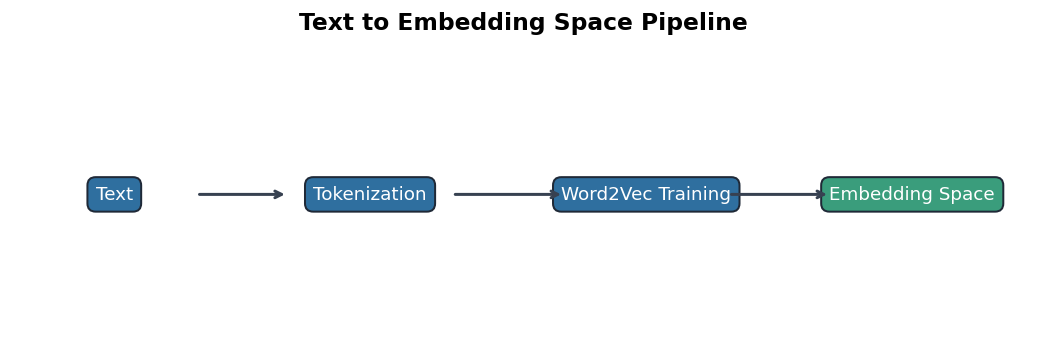

In [18]:
def plot_embedding_pipeline():
    """Draw a compact pipeline diagram for Word2Vec training."""
    fig, ax = plt.subplots(figsize=(11, 3))
    ax.axis("off")

    steps = [
        "Text",
        "Tokenization",
        "Word2Vec Training",
        "Embedding Space",
    ]
    x_positions = [0.1, 0.35, 0.62, 0.88]

    for index, (step, x_position) in enumerate(zip(steps, x_positions)):
        box_color = PRIMARY_COLOR if index < 3 else ACCENT_COLOR
        ax.text(
            x_position,
            0.5,
            step,
            ha="center",
            va="center",
            fontsize=11,
            color="white",
            bbox={
                "boxstyle": "round,pad=0.45",
                "facecolor": box_color,
                "edgecolor": "#1F2937",
                "linewidth": 1.2,
            },
        )

    for start, end in zip(x_positions[:-1], x_positions[1:]):
        ax.annotate(
            "",
            xy=(end - 0.08, 0.5),
            xytext=(start + 0.08, 0.5),
            arrowprops={"arrowstyle": "->", "lw": 1.8, "color": "#374151"},
        )

    ax.set_title("Text to Embedding Space Pipeline", pad=16)
    plt.show()


plot_embedding_pipeline()

## Embedding Limitations

Classic word embeddings are powerful, but they have several limitations:

- **Small datasets produce weak embeddings**: meaningful semantic structure requires many examples.
- **One vector per word**: static embeddings assign one representation to each word.
- **Limited context awareness**: the same vector is used for different meanings.
- **Out-of-vocabulary words**: unknown words cannot be represented unless the model has subword support.
- **Bias in training data**: embeddings can learn and amplify social or domain biases from the corpus.

For example, `bank` can mean a financial institution or the side of a river. A static Word2Vec vector cannot fully adapt to those different contexts. Transformer-based contextual embeddings address this by producing different representations depending on the sentence.

## From Word Embeddings to Sequence Models

Embeddings are often used as the input layer for neural sequence models. Instead of feeding raw tokens directly into a model, each token is mapped to a dense vector.

Important sequence model families include:

- **RNN**: processes tokens sequentially with recurrent hidden states,
- **LSTM**: improves RNNs with gates that help preserve longer-range information,
- **GRU**: a simpler gated recurrent architecture,
- **Transformer**: uses attention to model relationships between tokens more flexibly.

The next notebook moves from word-level representations to sequence modeling.

## Real-world Applications

Word embeddings and related dense representations are used in:

- semantic search,
- recommendation systems,
- sentiment analysis,
- text classification,
- chatbots,
- RAG systems,
- machine translation.

Even when modern systems use contextual embeddings, the core idea remains the same: represent language as vectors so models can compare, retrieve, classify, and generate text.

## Final Summary

Key takeaways:

- embeddings are learned dense vectors,
- similar words appear close in vector space,
- Word2Vec learns from context windows,
- embeddings are powerful but limited,
- contextual embeddings later improved this idea.

This notebook connected the intuition of word vectors to practical Word2Vec training and showed how learned embeddings can be inspected, compared, and visualized.

## Next Notebook

➡️ Next: RNN

The next notebook will move from word-level representations to sequence modeling.